---
format:
  html:
    other-links:
      - text: This notebook
        href: L20 Linear systems of equations.ipynb
      - text: preamble.jl
        href: preamble.jl
---


#  Linear Systems of Equations

::: {.callout-note}

These notes are mainly a record of what we discussed and are not a substitute for attending the lectures and reading books! If anything is unclear/wrong, let me know and I will update the notes. 

::: 

In [1]:
include("preamble.jl");

✓ file included! 

using: Plots, LaTeXStrings, Polynomials, PrettyTables, LinearAlgebra 

functions included: 
    Ch2: simple_iteration, Newton, orderOfConvergence, 
    Ch3: ChebyshevNodes, ChebyshevInterpolant, Lagrange, 

Use @doc <<function>> for help


## Chapter 5: Linear Systems of Equations

::: {.callout-note}
## Warm-up

1. How would you write the following system of equations as a matrix equation?

\begin{align*}
    3x - y + z &= 1 \\
    x-y-z &= 3\\
    y + z &= 0
\end{align*}

*Answer*: 

\begin{align}
    \begin{pmatrix}
        3 & -1 & 1 \\ 
        1 & -1 & -1 \\
        0 & 1 & 1
    \end{pmatrix}
    \begin{pmatrix}
    x \\ y \\ z
    \end{pmatrix}
    = 
    \begin{pmatrix}
    1 \\ 3 \\ 0
    \end{pmatrix}
\end{align}

2. Why is there a solution to this equation? *Answer*: The determinant of $A$ is non-zero. 
3. Use Cramer's rule to compute the inverse of $A$.
4. Therefore show that $x = 3, y = 4, z = -4$

Julia confirmed our findings:

:::

In [2]:
A = [3 -1 1 ; 1 -1 -1; 0 1 1]
b = [1 , 3, 0]

inv(A)

3×3 Matrix{Float64}:
 -5.55112e-17   1.0   1.0
 -0.5           1.5   2.0
  0.5          -1.5  -1.0

In [3]:
inv(A) * b 

3-element Vector{Float64}:
  3.000000000000001
  4.000000000000002
 -4.000000000000002

In [4]:
A \ b

3-element Vector{Float64}:
  3.0000000000000004
  4.000000000000001
 -4.000000000000001

Then we saw some examples that involve matrices and relate to previous topics you've seen:

::: {.callout-note}
## Polynomial interpolation (Chapter 3)

For distinct points $X = \{ x_0, \dots, x_n \}$ and values $\{y_0,\dots,y_n\}$ (which, in our case, were given by $y_j = f(x_j)$ for some function $f$), consider the *Lagrange interpolation problem*: find $p(x) = a_0 + a_1 x + a_2 x^2 + \dots + a_n x^n$ such that $p(x_j) = y_j$ for $j=0,\dots,n$. We saw that the solution can be written as $p(x) = \sum_{j=0}^n \ell_j(x) y_j$. The problem can also be written as the following matrix equation:

\begin{align}
    V \bm a 
    %
    := 
    \begin{pmatrix}
        1 & x_0 & x_0^2 & \cdots & x_0^n \\
         1 & x_1 & x_1^2 & \cdots & x_1^n \\
          1 & x_2 & x_2^2 & \cdots & x_2^n \\
          \vdots & \vdots & \vdots &\ddots & \vdots \\
           1 & x_n & x_n^2 & \cdots & x_n^n
    \end{pmatrix}
    \begin{pmatrix}
        a_0 \\ a_1 \\ a_2 \\ \vdots \\ a_n
    \end{pmatrix}
    %
    = \begin{pmatrix}
        y_0 \\ y_1 \\ y_2 \\ \vdots \\ y_n
    \end{pmatrix},
\end{align}

where the matrix $V$ is known as the *Vandermonde matrix*. Since $p$ exists for any choice of $\bm y$, we have already proved that $V$ is invertible and $\bm a = V^{-1} \bm y$. 

:::

0.39419514906422315
0.3941951490642238


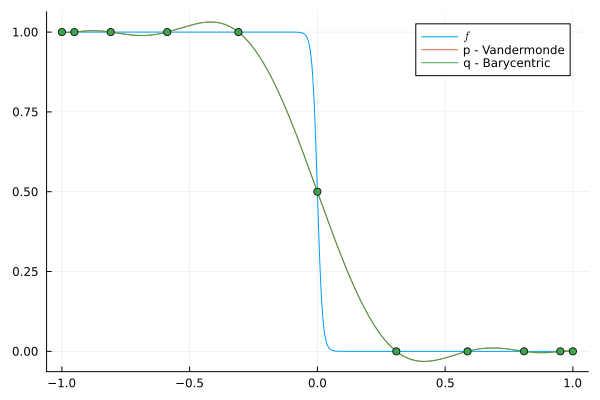

In [5]:
f = x -> 1 / (1 + exp(100 * x) ) 
e = -1:.001:1

N = 10;
X = ChebyshevNodes( N )
Y = f.(X) 
V = X.^(0:N)'

p = Polynomial( V \ Y )
q = ChebyshevInterpolant( f, N )

println( maximum( @. abs( f(e)-p(e) ) ) )
println( maximum( @. abs( f(e)-q(e) ) ) )

plot( f, -1, 1, label=L"f" ) 
plot!( p, -1, 1, label="p - Vandermonde" ) 
plot!( q, -1, 1, label="q - Barycentric" ) 
scatter!( X, Y, primary = false )

::: {.callout-note}
## Differential equations (Galerkin method)

Suppose you want to solve the differential equation $Lu = f$ where $L$ is some linear differential operator (e.g. $Lu(x) := u''(x) + g(x) u'(x) + h(x)$ for a general 2nd order linear differential equation). In order to solve this equation numerically, one may *discretise* it: introduce some finite set of functions $\{ \phi_j \}_{j=1}^N$ and suppose that $u \approx \sum_{j=1}^N c_j \phi_j$ for some coefficients $\bm c = (c_j)$. Then, multiplying by $\phi_i$ and integrating, one obtains

\begin{align}
    \int \phi_i(x) (Lu)(x) \mathrm{d}x 
    %
    &= \sum_i \int \phi_i(x) (L\phi_j)(x) \mathrm{d}x \,\, c_j \nonumber\\
    %
    &= \int \phi_i(x) f(x) \mathrm{d}x.  
\end{align}

This is the matrix equation $A \bm c = \bm f$ where

\begin{align}
    A_{ij} &:= \int \phi_i(x) (L\phi_j)(x) \mathrm{d}x \\
    f_{i} &:= \int \phi_i(x) f(x) \mathrm{d}x 
\end{align}

Solving this system gives the coefficients in the approximate solution $u$.


In the next assignmnet, we will solve 

\begin{align}
    -u''(x) &= f(x) \quad &\text{on } (-1,1) \\
    u(x) &= 0 \quad &\text{on } \{-1,1\}.
\end{align}

We choose a basis $\{ \phi_i \}$ and expand $u(x) = \sum_{i} c_i \phi_i(x)$. Since we require $u(x) = 0$ on $\{-1,1\}$, we shall choose the basis so that $\phi(-1) = \phi(1) = 0$. Let's choose Chebyshev points $X = \{x_0, \dots, x_n\}$ and choose the basis $\{ \ell_i \}_{i=1}^{n-1}$ of Lagrange polynomials (ommiting $i=0$ and $i=n$ so that $\phi_i(-1) = \phi_i(1) = 0$ for all basis functions).

:::

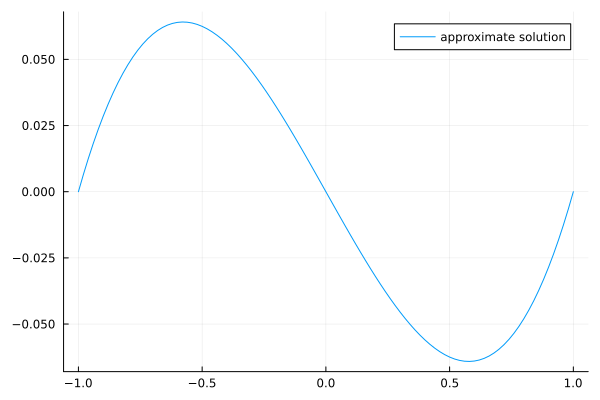

In [6]:
f = x->-x 

n = 100; 
X = ChebyshevNodes( n )[2:end-1]
A = zeros( n-1, n-1 )
S = zeros( n-1, n-1 )
F = zeros( n-1 )

# Approximate f with a polynomial
p = fit(ChebyshevT, X, f.(X))

φ = [ Lagrange( 1, n ) ];
for i = 2:(n-1)
    push!( φ, Lagrange( i, n ) )
end

for i = 1:(n-1) 
    F[i] = integrate( p * φ[i], -1, 1 )
    for j=1:(n-1)
        A[i,j] = integrate( derivative( φ[i] ) * derivative(φ[j]), -1, 1)
    end
end
c = A \ F
u = sum( c .* φ )

plot( u, -1, 1, label="approximate solution")

::: {.callout-note}
## Companion matrices 

The ```roots``` function in the Julia package ```Polynomials.jl``` finds the roots of a polynomial $p(x) = a_0 + a_1 x + \dots + a_n x^n$ by considering the following *Frobenius companion matrix*:

\begin{align}
    C = \begin{pmatrix}
        0 & 0 & \cdots & 0 & -a_0 \\
        1 &  &  &  & -a_1 \\
        & 1&  & & -a_2 \\
        & & \ddots & & \vdots \\
        & & & 1 & -a_n
    \end{pmatrix}.
\end{align}

It turns out that $p$ is the characteristic polynomial of $C$: that is, $p(x) = \det\big( xI - C \big)$. Therefore, one may find the roots of $p$ by computing eigenvalues of $C$ (which we will discuss in the following weeks). 

:::

## Cramer's Rule

We have the formula 

\begin{align*}
    [ A^{-1} ]_{ij} = \frac{(-1)^{i+j}}{\det A} \mathrm{cof}(A)_{ij} 
\end{align*}

where $\mathrm{cof}(A)$ is the transpose of the matrix where the $i,j$ entry is the determinant of the submatrix after removing row $i$ and column $j$.

The computational effort involved in computing $\det A$ by expanding on the first row (or any row) is $O(n!)$ where $A \in \mathbb R^{n\times n}$. 

If $n=100$ (which is small in many applications), $n! \approx 9 \times 10^{157}$, and so, if our computer can run $10^{12}$ operations per second (which is a lot), then it'll take $n! / 10^{12}$ seconds $ \approx 3 \times 10^{138}$ years. This is a long time! (Big bang $\approx 13 \times 10^9$ years ago)   

This means we need better methods!

## Gaussian Elimination

Let's go back to the example we started with:

::: {.callout-note}

Solve 

\begin{align*}
    3x - y + z &= 1 \\
    x-y-z &= 3\\
    y + z &= 0
\end{align*}

*Answer*: 

Adding the third equation to the second gives $x = 3$. Adding the third equation to the first gives $3x + 2z = 1$ and since $x = 3$, we have $z = -4$. The final equation then says that $y = 4$.

Alternatively, we can see this by using elementary row operations: First write the augmented matrix 

\begin{align}
     \begin{pmatrix}
        \bm r_1 \\ 
        \bm r_2\\
        \bm r_3
    \end{pmatrix}
    %
    = 
    \begin{pmatrix}
        3 & -1 & 1 &|& 1 \\ 
        1 & -1 & -1 &|& 3\\
        0 & 1 & 1 &|& 0 
    \end{pmatrix}
\end{align}

where row $i$ is denoted by $\bm r_i$.

Then, by doing the row operations indicated, we get 

\begin{align*}
\begin{pmatrix}
        3 & -1 & 1 &|& 1 \\ 
        1 & -1 & -1 &|& 3\\
        0 & 1 & 1 &|& 0 
    \end{pmatrix}
    &\stackrel{ \bm r_2 \to \bm r_2 + \bm r_3 }{\longrightarrow}
 \begin{pmatrix}
        3 & -1 & 1 &|& 1 \\ 
        1 & 0 & 0 &|& 3\\
        0 & 1 & 1 &|& 0 
    \end{pmatrix} \\
    &\stackrel{ \bm r_1 \to \bm r_1 + \bm r_3 }{\longrightarrow}
 \begin{pmatrix}
        3 & 0 & 2 &|& 1 \\ 
        1 & 0 & 0 &|& 3\\
        0 & 1 & 1 &|& 0 
    \end{pmatrix} \\
    %
     &\stackrel{ \bm r_1 \to \bm r_1 - 3\bm r_2 }{\longrightarrow}
 \begin{pmatrix}
        0 & 0 & 2 &|& -8 \\ 
        1 & 0 & 0 &|& 3\\
        0 & 1 & 1 &|& 0 
    \end{pmatrix} \\
     &\stackrel{ \bm r_1 \to \frac{1}{2}\bm r_1 }{\longrightarrow}
 \begin{pmatrix}
        0 & 0 & 1 &|& -4 \\ 
        1 & 0 & 0 &|& 3\\
        0 & 1 & 1 &|& 0 
    \end{pmatrix} \\
%
&\stackrel{ \bm r_3 \to \bm r_3 - \bm r_1 }{\longrightarrow}
 \begin{pmatrix}
       0 & 0 & 1 &|& -4 \\ 
        1 & 0 & 0 &|& 3\\
        0 & 1 & 0 &|& 4 
    \end{pmatrix} \\
&\stackrel{ \bm r_1 \leftrightarrow \bm r_2, \bm r_{2} \leftrightarrow \bm r_3 }{\longrightarrow}
 \begin{pmatrix}
        1 & 0 & 0 &|& 3\\
        0 & 1 & 0 &|& 4 \\
        0 & 0 & 1 &|& -4 
    \end{pmatrix} \\
\end{align*}

which reads $x=3, y= 4, z = -4$.

:::

This process is called Gaussian elimination (and is equivalent to how you would solve simultaneous equations at school).

::: {.callout-note}
# Examples 

What happens when you apply Gauss elimination to the following systems?

*(i)*

\begin{align*}
    x - y + 2z &= -8 \\
    2x - 2y + 3z &= -20 \\
    z &= 0
\end{align*}

*(ii)*

\begin{align*}
    x - y + z &=4 \\
    2y - z &= -2 \\
    3x + 3y &= 6
\end{align*}

:::

Exercises: Burden pg. 372

Notice that, if $A$ is invertible, then by doing row operations we get  

\begin{align}
    \begin{pmatrix}
        A &|& I 
    \end{pmatrix} 
    %
    \longrightarrow 
    %
    \begin{pmatrix}
        I &|& A^{-1} 
    \end{pmatrix}. 
\end{align}

It turns out that this process is $O(n^{3})$. Again, if $n=100$, a fast computer will compute the inverse in $100^3 / 10^{12} = 10^{-6}$ seconds $ \ll $ time since the big bang.

## LU Decomposition

Let $L$ be unit lower triangular (that is, $L_{ii} = 1$ and $L_{ij} = 0$ for all $i< j$) and $U$ be upper triangular (that is, $U_{ij} = 0$ for all $i>j$). Then, one can solve 

\begin{align}
    LU x = b
\end{align}

by solving 

\begin{align}
    L y = b \tag{forwards substitution} \\
    U x = y \tag{backwards substitution} 
\end{align}

::: {.callout-note}
## Example

Solve $LU x = b$ where 

\begin{align}
    L = \begin{pmatrix}
        1 & & &  \\
        3 & 1 & & \\
        4 & 2 & 1 & \\
        0 & 7 & 2 & 1      
    \end{pmatrix}, \qquad  
    %
    U = 
    \begin{pmatrix}
        4 & 1& 0 & 0  \\
         & 1 & 0 &1 \\
         &  & 1 & 0 \\
         &  &  & 2      
    \end{pmatrix}
    , \qquad b = \begin{pmatrix}
        1 \\ 1 \\ 1 \\ 1 
    \end{pmatrix}
\end{align}

:::

In [7]:
function forwardSub(L, b)
    n = size(L,1)
    y = zeros(n)
    y[1] = b[1] / L[1, 1]
    for i ∈ 2:n
        s = sum(L[i, j] * y[j] for j ∈ 1:i-1)
        y[i] = (b[i] - s) / L[i, i]
    end
    return y
end

function backwardSub(U, y)
    n = size(U, 1)
    x = zeros(n)
    x[n] = y[n] / U[n, n]
    for i ∈ n-1:-1:1
        s = sum(U[i, j] * x[j] for j ∈ i+1:n)
        x[i] = (y[i] - s) / U[i, i]
    end
    return x
end

L = [1 0 0 0 ; 3 1 0 0 ; 4 2 1 0 ; 0 7 2 1]
U = [4 1 0 0 ; 0 1 0 1 ; 0 0 1 0 ; 0 0 0 2]
A = L*U;
b = [1 ; 1 ; 1 ; 1]
y = forwardSub(L, b)
x = backwardSub(U, y)

4-element Vector{Float64}:
  2.375
 -8.5
  1.0
  6.5

```A \ B``` 

> "Matrix division using a polyalgorithm. For input matrices ```A``` and ```B```, the result ```X``` is such that ```AX = B``` when ```A``` is square. The solver that is used depends upon the structure of ```A```. If ```A``` is upper or lower triangular (or diagonal), no factorization of ```A``` is required and the system is solved with either forward or backward substitution. For non-triangular square matrices, an LU factorization is used."

In [8]:
A \ b

4-element Vector{Float64}:
  2.375000000000001
 -8.500000000000004
  0.9999999999999998
  6.500000000000003

In [9]:
A = rand(5000, 5000); b = rand(5000);
T = tril( A );

In [10]:
@time T \ b;

  0.030426 seconds (3 allocations: 39.179 KiB)


In [11]:
@time A \ b;

  2.565301 seconds (9 allocations: 190.811 MiB, 0.20% gc time)


## Computing LU decomposition

In [12]:
function LU_decomp( A )
    n = size(A, 1)      
    L = diagm(ones(n))  
    U = zeros(n, n)

    for j ∈ 1:n-1
        U[j, :] = A[j, :]
        L[:, j] = A[:, j] / U[j, j]
        A = A - L[:, j] * U[j, :]'
    end
    U[n, n] = A[n, n]

    return tril(L), triu(U)
end

A = [ 2 0 4 3 ; -4 5 -7 -10 ; 1 15 2 -9/2; -2 0 2 -13]
(L, U) = LU_decomp(A)

b = [1 ; 2 ; 1 ; 0]
y = forwardSub(L, b)
x = backwardSub(U, y)

4-element Vector{Float64}:
  53.333333333333336
  -4.366666666666666
 -18.166666666666668
 -11.0

In [13]:
A \ b

4-element Vector{Float64}:
  53.333333333333535
  -4.366666666666682
 -18.166666666666732
 -11.000000000000039

Example:

In [14]:
A = [ 1 2 -3 ; 0 1 -1 ; 1 1 0 ]
(L, U) = LU_decomp(A)
U

3×3 Matrix{Float64}:
 1.0  2.0  -3.0
 0.0  1.0  -1.0
 0.0  0.0   2.0

Unstable! 

In [15]:
A = [2 0 4 3 ; -2 0 2 -13 ; 1 15 2 -4.5 ; -4 5 -7 -10];
L, U = LU_decomp(A)
L

4×4 Matrix{Float64}:
  1.0    0.0    0.0  0.0
 -1.0  NaN      0.0  0.0
  0.5   Inf   NaN    0.0
 -2.0   Inf   NaN    1.0

Built in function works in this case though:

In [16]:
lu( A )

LU{Float64, Matrix{Float64}, Vector{Int64}}
L factor:
4×4 Matrix{Float64}:
  1.0    0.0       0.0        0.0
 -0.25   1.0       0.0        0.0
  0.5   -0.153846  1.0        0.0
 -0.5    0.153846  0.0833333  1.0
U factor:
4×4 Matrix{Float64}:
 -4.0   5.0   -7.0      -10.0
  0.0  16.25   0.25      -7.0
  0.0   0.0    5.53846   -9.07692
  0.0   0.0    0.0       -0.166667

We see next time we will see that using *pivotting strategies* alleviate this issue.